In [1]:
import numpy as np
import pandas as pd
import os, sys, time, glob
import json
import warnings
from tqdm import tqdm
from IPython.display import clear_output
from time import time
from time import sleep
import torch
from torch.utils.data import Dataset, DataLoader, TensorDataset, random_split
from os.path import exists
import matplotlib.pyplot as plt
import yaml
import bilby
from bilby.core.prior import Uniform, DeltaFunction
from bilby.core.prior import PriorDict

/home/malina.desai/.local/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
from dataprocessing import open_json
from dataprocessing import parse_prior_file
from dataprocessing import grab_injection_filtered
from dataprocessing import json_to_df
from dataprocessing import directory_json_to_df
from dataprocessing import build_time_grid_from_prior
from dataprocessing import align_lightcurve_to_grid

In [3]:
from dataprocessing import extract_number

In [4]:
# bands = ['ztfg', 'ztfr', 'ztfi']
# detection_limit = [22.0, 22.0, 22.0]
# dt = 0.5
# duration = 7
# dir_path = '/home/malina.desai/nmma/data/ztf_test/'
# prior_path = '/home/malina.desai/nmma/priors/Ka2017.prior'
# label = 'test'
# inj_file = 'injection_test.json'

In [5]:
bands = ['ztfg', 'ztfr', 'ztfi']
detection_limit = [22.0, 22.0, 22.0] 
# detection_limits = dict(zip(bands, detection_limit))
# detection_limits

In [7]:
def load_in_lightcurves(
    inj_path,
    dir_path,
    prior_path,
    label,
    bands,
    detection_limits,
    duration,
    dt,
    parameters,
    save_dir,
    coalescence_time = 44244.00022,
    round_decimals = 4,
):
    inj_df = grab_injection_filtered(inj_path = inj_path,
                                     prior_path = prior_path,
                                    )
    time_grid = build_time_grid_from_prior(prior_path = prior_path, 
                                           duration = duration, 
                                           dt = dt, 
                                           round_decimals = round_decimals,
                                          )
    # data_list = []
    # param_list = []

    for file in tqdm(sorted(os.listdir(dir_path), key=extract_number)):
        if file.endswith(".json") and file.startswith(label):
            df = json_to_df(
                file, dir_path, detection_limits, bands
            )
            sim_id = extract_number(file)

            df['simulation_id'] = sim_id
            inj_params = inj_df.loc[inj_df['simulation_id'] == sim_id]
            time_offset = inj_params['timeshift'].values[0]
            df = df.merge(inj_params, on='simulation_id')
            aligned_lc = align_lightcurve_to_grid(
                df = df,
                coalescence_time = coalescence_time,
                time_offset = time_offset,
                time_grid = time_grid,
                bands = bands,
                filler_value = detection_limits
            )
            data_tensor = torch.from_numpy(aligned_lc)
            # data_list.append(torch.from_numpy(aligned_lc))
            params = np.asarray(df.loc[0, parameters].to_list())
            param_tensor = torch.from_numpy(params).unsqueeze(0)
            # param_list.append(param_tensor)
            torch.save(data_tensor, save_dir + '/{}_data_{}.pt'.format(label, sim_id))
            torch.save(param_tensor, save_dir + '/{}_params_{}.pt'.format(label, sim_id))
    
    

In [14]:
detection_limit = [22.0, 22.0, 22.0] 
load_in_lightcurves(inj_path = '/home/malina.desai/nmma/injection_files/injection_fixed.json',
                    dir_path = '/home/malina.desai/nmma/data/mehul_fixed_lowc/',
                    prior_path = '/home/malina.desai/nmma/priors/Ka2017.prior',
                    label = 'test_fixed',
                    bands = ['ztfg', 'ztfr', 'ztfi'],
                    detection_limits = dict(zip(bands, detection_limit)),
                    duration = 22,
                    dt = 0.5,
                    parameters = ['luminosity_distance', 'timeshift', 'log10_mej', 'log10_vej', 'log10_Xlan'],
                    save_dir = '/home/malina.desai/nmma/data/mehul_embedding_tensors_fixed_lowc'
                                           )
    

  3%|▎         | 17429/500001 [06:43<3:06:12, 43.19it/s] 

KeyboardInterrupt



In [13]:
dir_path = '/home/malina.desai/nmma/data/mehul_flow_lowc/'
tensors = []

for i in tqdm(range(0, 250000)):
    file_path = os.path.join(dir_path, f'nflow_params_{i}.pt')
    if not os.path.exists(file_path):
        print(f"Skipping missing file: {file_path}")
        continue
    
    tensor = torch.load(file_path)
    tensors.append(tensor)

# Stack into one giant tensor
big_tensor = torch.stack(tensors)

# Save as one file
out_path = os.path.join(dir_path, 'flow_tensors_params.pt')
torch.save(big_tensor, out_path)

print(f"Saved stacked tensor to {out_path} with shape {big_tensor.shape}")

100%|██████████| 250000/250000 [22:35<00:00, 184.47it/s] 


Saved stacked tensor to /home/malina.desai/nmma/data/mehul_flow_lowc/flow_tensors_params.pt with shape torch.Size([250000, 1, 5])


In [ ]:
def tensor_stacking(
dir_path,
out_path,
):
    tensors = []
    for i in tqdm(sorted(os.listdir(dir_path), key=extract_number):
        file_path = os.path.join(dir_path, f'nflow_data_{key}.pt')
        if not os.path.exists(file_path):
            print(f"Skipping missing file: {file_path}")
            continue

        tensor = torch.load(file_path)
        tensors.append(tensor)
    big_tensor = torch.stack(tensors)
    torch.save(big_tensor, out_path)
    print(f"Saved stacked tensor to {out_path} with shape {big_tensor.shape}")

In [23]:
ex_1.shape

torch.Size([3, 61])

In [69]:
inj_path = '/home/malina.desai/nmma/injection_files/injection_fixed.json'
dir_path = '/home/malina.desai/nmma/data/mehul_fixed_lowc/'
prior_path = '/home/malina.desai/nmma/priors/Ka2017.prior'
label = 'test_fixed'
bands = ['ztfg', 'ztfr', 'ztfi']
detection_limits = dict(zip(bands, detection_limit))
duration = 22
dt = 0.5
round_decimals = 4
coalescence_time = 44244.00022
parameters = ['luminosity_distance', 'timeshift', 'log10_mej', 'log10_vej', 'log10_Xlan']

In [70]:
inj_df = grab_injection_filtered(inj_path = inj_path,
                                     prior_path = prior_path,
                                    )
time_grid = build_time_grid_from_prior(prior_path = prior_path, 
                                       duration = duration, 
                                       dt = dt, 
                                       round_decimals = round_decimals,
                                      )
data_list = []
param_list = []

for file in tqdm(sorted(os.listdir(dir_path), key=extract_number)):
    if file.endswith(".json") and file.startswith(label):
        df = json_to_df(
            file, dir_path, detection_limits, bands
        )
        sim_id = extract_number(file)

        df['simulation_id'] = sim_id
        inj_params = inj_df.loc[inj_df['simulation_id'] == sim_id]
        time_offset = inj_params['timeshift'].values[0]
        df = df.merge(inj_params, on='simulation_id')
        aligned_lc = align_lightcurve_to_grid(
            df = df,
            coalescence_time = coalescence_time,
            time_offset = time_offset,
            time_grid = time_grid,
            bands = bands,
            filler_value = detection_limits
        )
        data_list.append(torch.from_numpy(aligned_lc))
        params = np.asarray(df.loc[0, parameters].to_list())
        param_tensor = torch.from_numpy(params).unsqueeze(0)
        param_list.append(param_tensor)
        break

  0%|          | 0/500001 [00:00<?, ?it/s]


In [71]:
params

array([50.        ,  0.        , -1.18382358, -0.61260815, -3.65352565])

In [76]:
data_list

[tensor([[22.0000, 22.0000, 22.0000, 22.0000, 22.0000, 19.4100, 18.3898, 19.1046,
          19.4244, 19.8304, 20.2221, 20.6679, 20.8484, 21.5115, 21.5673, 21.8582,
          21.8575, 22.0000, 22.0000, 22.0000, 22.0000, 22.0000, 22.0000, 22.0000,
          22.0000, 22.0000, 22.0000, 22.0000, 22.0000, 22.0000, 22.0000, 22.0000,
          22.0000, 22.0000, 22.0000, 22.0000, 22.0000, 22.0000, 22.0000, 22.0000,
          22.0000, 22.0000, 22.0000, 22.0000, 22.0000, 22.0000, 22.0000, 22.0000,
          22.0000, 22.0000, 22.0000, 22.0000, 22.0000, 22.0000, 22.0000, 22.0000,
          22.0000, 22.0000, 22.0000, 22.0000, 22.0000],
         [22.0000, 22.0000, 22.0000, 22.0000, 22.0000, 18.6920, 16.9914, 17.4304,
          17.8164, 18.2489, 18.5978, 18.9115, 19.1600, 19.3032, 19.4329, 19.5761,
          19.8887, 20.1068, 19.9667, 20.3414, 20.5576, 20.5997, 20.9962, 22.0000,
          22.0000, 22.0000, 22.0000, 22.0000, 22.0000, 22.0000, 22.0000, 22.0000,
          22.0000, 22.0000, 22.0000, 22.00

In [77]:
param_list

[tensor([[50.0000,  0.0000, -1.1838, -0.6126, -3.6535]], dtype=torch.float64)]

In [78]:
data_list[0].shape

torch.Size([3, 61])

In [79]:
param_list[0].shape

torch.Size([1, 5])

In [21]:
df.loc[df['filter'] == 'ztfg']

,filter,time,mag,num_detections,simulation_id,luminosity_distance,timeshift,log10_mej,log10_vej,log10_Xlan
0,ztfg,44242.309713,22.000000,10,0,106.73278,-1.690507,-2.264906,-0.988926,-6.32932
1,ztfg,44242.809713,22.000000,10,0,106.73278,-1.690507,-2.264906,-0.988926,-6.32932
2,ztfg,44243.309713,21.365331,10,0,106.73278,-1.690507,-2.264906,-0.988926,-6.32932
3,ztfg,44243.809713,22.000000,10,0,106.73278,-1.690507,-2.264906,-0.988926,-6.32932
4,ztfg,44244.309713,22.000000,10,0,106.73278,-1.690507,-2.264906,-0.988926,-6.32932
5,ztfg,44244.809713,22.000000,10,0,106.73278,-1.690507,-2.264906,-0.988926,-6.32932
6,ztfg,44245.309713,22.000000,10,0,106.73278,-1.690507,-2.264906,-0.988926,-6.32932
7,ztfg,44245.809713,22.000000,10,0,106.73278,-1.690507,-2.264906,-0.988926,-6.32932
8,ztfg,44246.309713,22.000000,10,0,106.73278,-1.690507,-2.264906,-0.988926,-6.32932
9,ztfg,44246.809713,22.000000,10,0,106.73278,-1.690507,-2.264906,-0.988926,-6.32932


In [24]:
len(aligned_lc[0])

21

In [5]:
directory_json_to_df(dir_path = dir_path, label = label, detection_limits = detection_limits, bands = bands)

[   filter          time        mag  num_detections  simulation_id
 0    ztfg  44242.309713  22.000000              10              0
 1    ztfg  44242.809713  22.000000              10              0
 2    ztfg  44243.309713  21.365331              10              0
 3    ztfg  44243.809713  22.000000              10              0
 4    ztfg  44244.309713  22.000000              10              0
 5    ztfg  44244.809713  22.000000              10              0
 6    ztfg  44245.309713  22.000000              10              0
 7    ztfg  44245.809713  22.000000              10              0
 8    ztfg  44246.309713  22.000000              10              0
 9    ztfg  44246.809713  22.000000              10              0
 10   ztfg  44247.309713  22.000000              10              0
 11   ztfg  44247.809713  22.000000              10              0
 12   ztfg  44248.309713  22.000000              10              0
 13   ztfg  44248.809713  22.000000              10           

In [5]:
df_list = directory_json_to_df(dir_path = dir_path, 
                               label = label, 
                               detection_limits = detection_limits, 
                               bands = bands
                              )

In [8]:
inj_df = grab_injection_filtered(inj_file = inj_file,
                        dir_path = dir_path,
                        prior_path = prior_path
                         )

In [9]:
inj_df

,luminosity_distance,timeshift,log10_mej,log10_vej,log10_Xlan,simulation_id
0,106.732780,-1.690507,-2.264906,-0.988926,-6.329320,0
1,34.479060,-1.758973,-2.847407,-1.290640,-6.084976,1
2,1.999755,-0.285639,-2.525499,-0.690679,-2.424844,2
3,66.887441,-0.419443,-2.678916,-0.579932,-4.812344,3
4,22.353711,0.755251,-2.926047,-1.499790,-8.584715,4
5,199.073116,-0.734978,-2.461902,-1.178515,-5.360663,5
6,127.837393,-1.695973,-1.407930,-0.561339,-3.339005,6
7,14.211515,-1.285361,-2.422200,-1.140210,-4.934433,7
8,174.387896,-1.291723,-1.995532,-1.253484,-8.441002,8
9,142.871383,-1.186466,-1.472927,-0.733393,-3.301800,9


In [21]:
df_list[0]

,filter,time,mag,num_detections,simulation_id,luminosity_distance,timeshift,log10_mej,log10_vej,log10_Xlan
0,ztfg,44242.309713,22.000000,10,0,106.73278,-1.690507,-2.264906,-0.988926,-6.32932
1,ztfg,44242.809713,22.000000,10,0,106.73278,-1.690507,-2.264906,-0.988926,-6.32932
2,ztfg,44243.309713,21.365331,10,0,106.73278,-1.690507,-2.264906,-0.988926,-6.32932
3,ztfg,44243.809713,22.000000,10,0,106.73278,-1.690507,-2.264906,-0.988926,-6.32932
4,ztfg,44244.309713,22.000000,10,0,106.73278,-1.690507,-2.264906,-0.988926,-6.32932
5,ztfg,44244.809713,22.000000,10,0,106.73278,-1.690507,-2.264906,-0.988926,-6.32932
6,ztfg,44245.309713,22.000000,10,0,106.73278,-1.690507,-2.264906,-0.988926,-6.32932
7,ztfg,44245.809713,22.000000,10,0,106.73278,-1.690507,-2.264906,-0.988926,-6.32932
8,ztfg,44246.309713,22.000000,10,0,106.73278,-1.690507,-2.264906,-0.988926,-6.32932
9,ztfg,44246.809713,22.000000,10,0,106.73278,-1.690507,-2.264906,-0.988926,-6.32932


In [17]:
inj_file.loc[inj_file['simulation_id'] == 0]['timeshift'].values

array([-1.690507])

In [18]:
inj_file

,simulation_id,luminosity_distance,timeshift,log10_mej,log10_vej,log10_Xlan,geocent_time
0,0,106.732780,-1.690507,-2.264906,-0.988926,-6.329320,0.026823
1,1,34.479060,-1.758973,-2.847407,-1.290640,-6.084976,-0.098807
2,2,1.999755,-0.285639,-2.525499,-0.690679,-2.424844,-0.002001
3,3,66.887441,-0.419443,-2.678916,-0.579932,-4.812344,0.034075
4,4,22.353711,0.755251,-2.926047,-1.499790,-8.584715,0.089584
5,5,199.073116,-0.734978,-2.461902,-1.178515,-5.360663,-0.016323
6,6,127.837393,-1.695973,-1.407930,-0.561339,-3.339005,-0.076994
7,7,14.211515,-1.285361,-2.422200,-1.140210,-4.934433,-0.087431
8,8,174.387896,-1.291723,-1.995532,-1.253484,-8.441002,0.076489
9,9,142.871383,-1.186466,-1.472927,-0.733393,-3.301800,-0.002309


In [23]:
44242.309713 -  -1.690507

44244.00022

In [24]:
44242.241246 - -1.758973

44244.000219

In [ ]:
44243.714581 - -0.285639

In [25]:
df_list[2].head()

,filter,time,mag,num_detections,simulation_id
0,ztfg,44243.714581,22.000000,44,2
1,ztfg,44244.214581,17.802681,44,2
2,ztfg,44244.714581,18.146447,44,2
3,ztfg,44245.214581,19.260852,44,2
4,ztfg,44245.714581,19.822622,44,2


In [83]:
time_grid = build_time_grid_from_prior(priors = priors,
                                       duration = duration,
                                       dt = dt,
                                      )
time_grid

array([-2. , -1.5, -1. , -0.5,  0. ,  0.5,  1. ,  1.5,  2. ,  2.5,  3. ,
        3.5,  4. ,  4.5,  5. ,  5.5,  6. ,  6.5,  7. ,  7.5,  8. ,  8.5,
        9. ,  9.5, 10. , 10.5, 11. , 11.5, 12. , 12.5, 13. ])

In [84]:
len(time_grid)

31

In [85]:
def align_lightcurve_to_grid(
    df: pd.DataFrame,
    coalescence_time: float,
    time_offset: float,
    time_grid: np.ndarray,
    bands: list,
    filler_value: dict,
) -> np.ndarray:
    """
    Aligns a single light curve to a fixed time grid, padding as necessary.

    Parameters
    ----------
    df : pd.DataFrame
        Light curve with columns ['time', 'band', 'mag'].
    coalescence_time : float
        The absolute coalescence time in days (e.g., 44244).
    time_offset : float
        The offset (in days) applied to this light curve (e.g., -1.6).
    time_grid : np.ndarray
        1D array of uniformly spaced time points (relative to coalescence).
    bands : list
        List of band names in canonical order (e.g., ['ztfg', 'ztfr', 'ztfi']).
    filler_value : dict
        Dict mapping each band name to a filler magnitude (e.g., {'ztfg': 22.0, ...}).

    Returns
    -------
    np.ndarray
        2D array of shape [num_bands, len(time_grid)] with aligned light curve.
    """
    # Convert light curve times to coalescence-relative time
    t_rel = df["time"] - coalescence_time

    # Apply the offset shift
    shifted_time = t_rel - time_offset
    df = df.copy()
    df["shifted_time"] = shifted_time

    # Prepare the output tensor [bands x time]
    aligned = np.zeros((len(bands), len(time_grid)))

    for b_idx, band in enumerate(bands):
        # Filter only this band
        band_data = df[df['filter'] == band]
        # Create array filled with the filler value
        band_array = np.full(len(time_grid), filler_value[band])

        # For each point, find the closest grid index and overwrite
        for _, row in band_data.iterrows():
            # Find index in grid nearest to shifted time
            idx = np.abs(time_grid - row["shifted_time"]).argmin()
            band_array[idx] = row["mag"]

        aligned[b_idx] = band_array

    return aligned


In [86]:
coalescence_time = 44244.00022
time_offset = -1.690507

In [87]:
df = df_list[0]
df.head()

,filter,time,mag,num_detections,simulation_id
0,ztfg,44242.309713,22.000000,10,0
1,ztfg,44242.809713,22.000000,10,0
2,ztfg,44243.309713,21.365331,10,0
3,ztfg,44243.809713,22.000000,10,0
4,ztfg,44244.309713,22.000000,10,0


In [88]:
t_rel = df["time"] - coalescence_time
t_rel[0:5]

0   -1.690507
1   -1.190507
2   -0.690507
3   -0.190507
4    0.309493
Name: time, dtype: float64

In [89]:
shifted_time = t_rel - time_offset
shifted_time[0:5]

0    2.163804e-07
1    5.000002e-01
2    1.000000e+00
3    1.500000e+00
4    2.000000e+00
Name: time, dtype: float64

In [90]:
df = df.copy()
df["shifted_time"] = shifted_time
df.head()

,filter,time,mag,num_detections,simulation_id,shifted_time
0,ztfg,44242.309713,22.000000,10,0,2.163804e-07
1,ztfg,44242.809713,22.000000,10,0,5.000002e-01
2,ztfg,44243.309713,21.365331,10,0,1.000000e+00
3,ztfg,44243.809713,22.000000,10,0,1.500000e+00
4,ztfg,44244.309713,22.000000,10,0,2.000000e+00


In [91]:
aligned = np.zeros((len(bands), len(time_grid)))
aligned

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [92]:
len(time_grid)

31

In [93]:
detection_limits['ztfg']

22.0

In [94]:
for b_idx, band in enumerate(bands):
    print(band)
    band_data = df[df['filter'] == band]
    band_array = np.full(len(time_grid), detection_limits[band])
    print(band_array)

ztfg
[22. 22. 22. 22. 22. 22. 22. 22. 22. 22. 22. 22. 22. 22. 22. 22. 22. 22.
 22. 22. 22. 22. 22. 22. 22. 22. 22. 22. 22. 22. 22.]
ztfr
[22. 22. 22. 22. 22. 22. 22. 22. 22. 22. 22. 22. 22. 22. 22. 22. 22. 22.
 22. 22. 22. 22. 22. 22. 22. 22. 22. 22. 22. 22. 22.]
ztfi
[22. 22. 22. 22. 22. 22. 22. 22. 22. 22. 22. 22. 22. 22. 22. 22. 22. 22.
 22. 22. 22. 22. 22. 22. 22. 22. 22. 22. 22. 22. 22.]


In [104]:
data = align_lightcurve_to_grid(
    df=df_list[0],
    coalescence_time = coalescence_time,
    time_offset = time_offset,
    time_grid = time_grid,
    bands = bands,
    filler_value= detection_limits,
)
print(data.shape)  # (3, len(time_grid))


(3, 31)


In [105]:
aligned

array([[22.        , 22.        , 22.        , 22.        , 22.        ,
        22.        , 21.36533099, 22.        , 22.        , 22.        ,
        22.        , 22.        , 22.        , 22.        , 22.        ,
        22.        , 22.        , 22.        , 22.        , 22.        ,
        22.        , 22.        , 22.        , 22.        , 22.        ,
        22.        , 22.        , 22.        , 22.        , 22.        ,
        22.        ],
       [22.        , 22.        , 22.        , 22.        , 22.        ,
        22.        , 20.66512306, 20.99178067, 21.29595933, 21.57540746,
        21.79144148, 21.98925811, 22.        , 22.        , 22.        ,
        22.        , 22.        , 22.        , 22.        , 22.        ,
        22.        , 22.        , 22.        , 22.        , 22.        ,
        22.        , 22.        , 22.        , 22.        , 22.        ,
        22.        ],
       [22.        , 22.        , 22.        , 22.        , 22.        ,
       

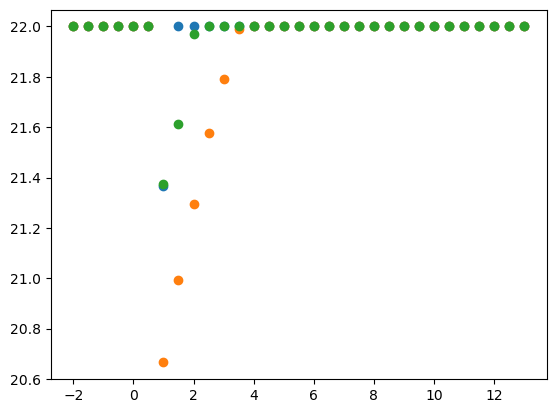

In [107]:
plt.scatter(time_grid, data[0])
plt.scatter(time_grid, data[1])
plt.scatter(time_grid, data[2])

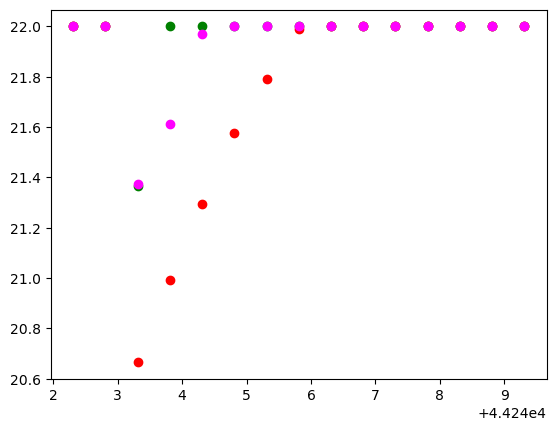

In [108]:
plt.scatter(df[df['filter'] == 'ztfg']['time'], df[df['filter'] == 'ztfg']['mag'], label = 'g', color = 'green')
plt.scatter(df[df['filter'] == 'ztfr']['time'], df[df['filter'] == 'ztfr']['mag'], label = 'r', color = 'r')
plt.scatter(df[df['filter'] == 'ztfi']['time'], df[df['filter'] == 'ztfi']['mag'], label = 'i', color = 'magenta')

In [34]:
df_list = directory_json_to_df(dir_path = '/home/malina.desai/nmma/data/ztf_test/', 
                               label = 'test', 
                               detection_limits = detection_limits, 
                               bands = bands
                              )

In [43]:
all_times = []
round_to = 4
for df in df_list:
    rounded_times = np.round(df['time'].values, round_to)
    all_times.append(rounded_times)
global_time_grid = np.unique(np.concatenate(all_times))
num_times = len(global_time_grid)
num_bands = len(bands)
batch_size = len(df_list)

In [45]:
len(global_time_grid)

150

In [ ]:
global_time_grid

In [ ]:
def prepare_lightcurve_batch(lightcurves, bands, filler_value=99.0, round_to=4):
    """
    Pads and aligns multiple light curves (with varying time grids) to a global time grid.
    
    Parameters:
    - lightcurves: list of DataFrames, each with columns ['filter', 'time', 'mag']
    - bands: list of expected photometric bands (e.g., ['ps1__g', 'ps1__r', ...])
    - filler_value: float, magnitude to use for missing entries
    - round_to: int, decimal precision to round time to (default: 4 = ~8.6 sec)

    Returns:
    - data_tensor: torch.Tensor, shape [batch_size, num_bands, num_times]
    - mask_tensor: torch.BoolTensor, shape [batch_size, num_bands, num_times]
    - global_time_grid: np.ndarray of aligned time values
    """

    # Step 1: Collect all unique rounded times
    all_times = []
    for df in lightcurves:
        rounded_times = np.round(df['time'].values, round_to)
        all_times.append(rounded_times)
    global_time_grid = np.unique(np.concatenate(all_times))
    num_times = len(global_time_grid)
    num_bands = len(bands)
    batch_size = len(lightcurves)

    # Step 2: Prepare tensors
    data_tensor = torch.full((batch_size, num_bands, num_times), filler_value, dtype=torch.float32)
    mask_tensor = torch.zeros((batch_size, num_bands, num_times), dtype=torch.bool)

    band_to_idx = {b: i for i, b in enumerate(bands)}
    time_to_idx = {t: i for i, t in enumerate(global_time_grid)}

    # Step 3: Fill in data
    for b, df in enumerate(lightcurves):
        df = df.copy()
        df['time'] = df['time'].round(round_to)
        for _, row in df.iterrows():
            band = row['filter']
            time = row['time']
            mag = row['mag']

            if band in band_to_idx and time in time_to_idx:
                i_band = band_to_idx[band]
                i_time = time_to_idx[time]
                data_tensor[b, i_band, i_time] = mag
                mask_tensor[b, i_band, i_time] = True

    return data_tensor, mask_tensor, global_time_grid


In [39]:
df_list[0]['time'][0] - df_list[0]['time'][1]

-0.5

In [14]:
df1 = json_to_df(file_name = 'test_0.json', 
                dir_path = '/home/malina.desai/nmma/data/ztf_test/', 
                detection_limits = detection_limits,
                bands = bands
               )

In [ ]:
    all_times = np.sort(df['time'].unique())
    padded_records = []
    num_detections = df['num_detections'][0]
    for band in bands:
        df_band = df[df['filter'] == band].set_index('time')
        for t in all_times:
            if t in df_band.index:
                row = df_band.loc[t]
                padded_records.append({
                    'time': t,
                    'filter': band,
                    'mag': row['mag'],
                    'num_detections': num_detections
                })
            else:
                padded_records.append({
                    'time': t,
                    'filter': band,
                    'mag': data_fillers[band],
                    'num_detections': num_detections
                })
    df_padded = pd.DataFrame(padded_records)

In [15]:
df_padded = pad_the_data(df = df,
                         data_fillers = detection_limits,
                         bands = bands)
                         

In [16]:
df_padded

,time,filter,mag,num_detections
0,44242.309713,ztfg,22.000000,10
1,44242.809713,ztfg,22.000000,10
2,44243.309713,ztfg,21.365331,10
3,44243.809713,ztfg,22.000000,10
4,44244.309713,ztfg,22.000000,10
5,44244.809713,ztfg,22.000000,10
6,44245.309713,ztfg,22.000000,10
7,44245.809713,ztfg,22.000000,10
8,44246.309713,ztfg,22.000000,10
9,44246.809713,ztfg,22.000000,10


In [30]:
len(df[df['filter'] == 'ztfg'])

15

In [17]:
import matplotlib.pyplot as plt

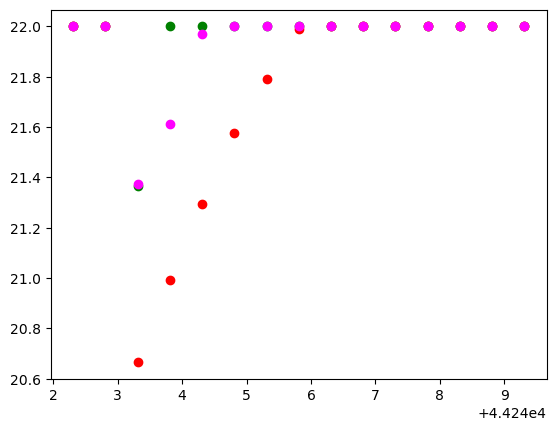

In [18]:
plt.scatter(df_padded[df_padded['filter'] == 'ztfg']['time'], df_padded[df_padded['filter'] == 'ztfg']['mag'], label = 'g', color = 'green')
plt.scatter(df_padded[df_padded['filter'] == 'ztfr']['time'], df_padded[df_padded['filter'] == 'ztfr']['mag'], label = 'r', color = 'r')
plt.scatter(df_padded[df_padded['filter'] == 'ztfi']['time'], df_padded[df_padded['filter'] == 'ztfi']['mag'], label = 'i', color = 'magenta')

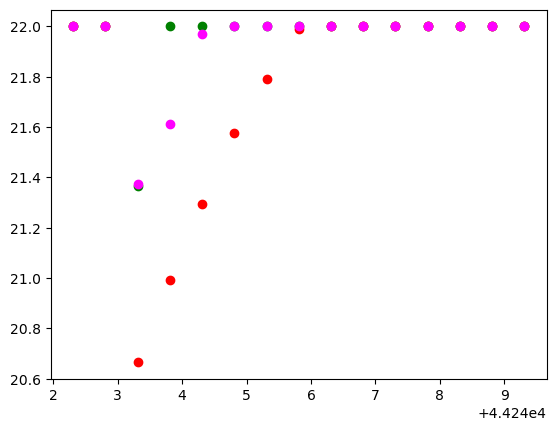

In [22]:
plt.scatter(df[df['filter'] == 'ztfg']['time'], df[df['filter'] == 'ztfg']['mag'], label = 'g', color = 'green')
plt.scatter(df[df['filter'] == 'ztfr']['time'], df[df['filter'] == 'ztfr']['mag'], label = 'r', color = 'r')
plt.scatter(df[df['filter'] == 'ztfi']['time'], df[df['filter'] == 'ztfi']['mag'], label = 'i', color = 'magenta')

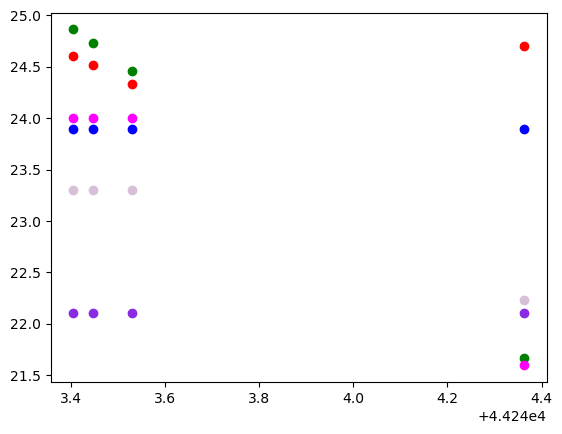

In [11]:
plt.scatter(df_padded[df_padded['filter'] == 'sdssu']['time'], df_padded[df_padded['filter'] == 'sdssu']['mag'], label = 'u', color = 'b')
plt.scatter(df_padded[df_padded['filter'] == 'ps1__g']['time'], df_padded[df_padded['filter'] == 'ps1__g']['mag'], label = 'g', color = 'green')
plt.scatter(df_padded[df_padded['filter'] == 'ps1__r']['time'], df_padded[df_padded['filter'] == 'ps1__r']['mag'], label = 'r', color = 'r')
plt.scatter(df_padded[df_padded['filter'] == 'ps1__i']['time'], df_padded[df_padded['filter'] == 'ps1__i']['mag'], label = 'i', color = 'magenta')
plt.scatter(df_padded[df_padded['filter'] == 'ps1__z']['time'], df_padded[df_padded['filter'] == 'ps1__z']['mag'], label = 'z', color = 'thistle')
plt.scatter(df_padded[df_padded['filter'] == 'ps1__y']['time'], df_padded[df_padded['filter'] == 'ps1__y']['mag'], label = 'y', color = 'blueviolet')

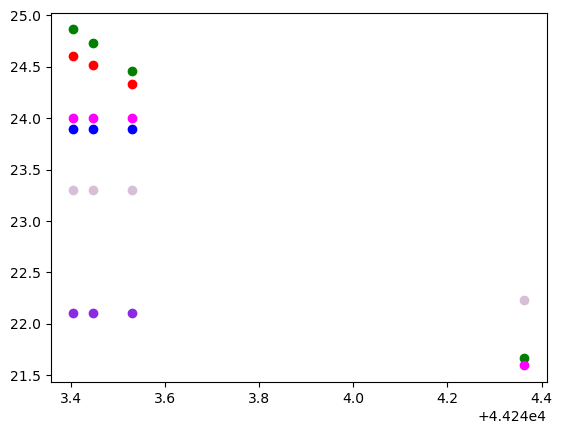

In [12]:
plt.scatter(df[df['filter'] == 'sdssu']['time'], df[df['filter'] == 'sdssu']['mag'], label = 'u', color = 'b')
plt.scatter(df[df['filter'] == 'ps1__g']['time'], df[df['filter'] == 'ps1__g']['mag'], label = 'g', color = 'green')
plt.scatter(df[df['filter'] == 'ps1__r']['time'], df[df['filter'] == 'ps1__r']['mag'], label = 'r', color = 'r')
plt.scatter(df[df['filter'] == 'ps1__i']['time'], df[df['filter'] == 'ps1__i']['mag'], label = 'i', color = 'magenta')
plt.scatter(df[df['filter'] == 'ps1__z']['time'], df[df['filter'] == 'ps1__z']['mag'], label = 'z', color = 'thistle')
plt.scatter(df[df['filter'] == 'ps1__y']['time'], df[df['filter'] == 'ps1__y']['mag'], label = 'y', color = 'blueviolet')

In [8]:
44243.446471 - 44243.404804

0.041667000004963484

In [17]:
t_min = df['time'].min()
t_max = df['time'].max()
print(t_min, t_max)
step = 0.5

44243.40480439417 44244.36313772751


In [21]:
44243.40480439417 + step + step

44244.40480439417

In [18]:
full_time = np.arange(t_min, t_max + step, step)
full_time

array([44243.40480439, 44243.90480439, 44244.40480439])

In [19]:
np.arange(0, 1, 3)

array([0])

In [ ]:
    # df = df.copy()
    # df = df.sort_values('t').reset_index(drop=True)
    full_time = np.arange(t_min, t_max, step)
    num_points = len(full_time)
    t_start = df['t'].min()
    t_end = df['t'].max()
    prepend_times = full_time[full_time < t_start]
    append_times = full_time[full_time > t_end]

    def make_filler(times):
        return pd.DataFrame({
            't': times,
            **{band: [val] * len(times) for band, val in zip(bands, data_fillers)},
            'simulation_id': np.nan,
            'num_detections': np.nan
        })

    prepend_df = make_filler(prepend_times)
    append_df = make_filler(append_times)
    df_padded = pd.concat([prepend_df, df, append_df], ignore_index=True)
    df_padded = df_padded.sort_values('t').reset_index(drop=True)
    assert np.isclose(df_padded['t'].min(), t_min), \
    f"Start time is {df_padded['t'].min()}, expected {t_min}"
    assert np.isclose(df_padded['t'].max(), t_max - step), \
    f"End time is {df_padded['t'].max()}, expected {t_max - step}"
    try:
        assert len(df_padded) == num_points+1, \
        f"Lengthb is {len(df_padded)}, expected {num_points+1}"
    except AssertionError as e:
        count = num_points + 1 - len(df_padded)
        addt_times = np.arange(t_max, t_max+(step*count), step)
        addt_append = make_filler(addt_times)
        df_padded = pd.concat([df_padded, addt_append], ignore_index=True)
        df_padded = df_padded.sort_values('t').reset_index(drop=True)
        assert len(df_padded) == num_points+1, \
        f"Length is {len(df_padded)}, expected {num_points+1}"

In [ ]:
def pad_band_dataframe(df_band, t_min, t_max, step, filler_value):
    """
    Pads a single-band light curve dataframe with dummy magnitudes where time is missing.
    
    Parameters:
    - df_band: DataFrame with ['time', 'mag'], possibly others (assumed sorted)
    - t_min, t_max: float, global time range
    - step: float, time step size
    - filler_value: float, magnitude to use when no observation exists at a time

    Returns:
    - df_padded: DataFrame with one row per time step in [t_min, t_max]
    """
    full_time = np.arange(t_min, t_max + step, step)

    # Create full time grid
    df_full = pd.DataFrame({'time': full_time})

    # Merge original data onto full grid
    df_merged = pd.merge(df_full, df_band, on='time', how='left')

    # Fill in missing magnitudes
    df_merged['mag'] = df_merged['mag'].fillna(filler_value)

    # Fill other columns as needed
    if 'filter' in df_band.columns:
        df_merged['filter'] = df_band['filter'].iloc[0]
    if 'simulation_id' in df_band.columns:
        df_merged['simulation_id'] = df_band['simulation_id'].iloc[0]
    if 'is_detection' in df_band.columns:
        df_merged['is_detection'] = df_merged['is_detection'].fillna(False)

    return df_merged
